# Validating the L0 reference *without* external ground truth
This notebook bounds how far L0 sits from reality three ways, each self-contained:

1. **Held-out interpolation error**:L0 assumes *linear* interpolation between AIS samples (Chapter 5). Test
   it against the data itself: drop an observed point, interpolate it from its neighbours, measure the
   displacement. The observed points *are* the truth for this test.
2. **Cleaning / population audit**: how many vessels and points the cleaning drops (raw -> L0), bounding how
   far L0's population is from the raw observed population.
Run from `benchmark/`.

In [1]:
import duckdb, pandas as pd, matplotlib.pyplot as plt
con=duckdb.connect(); con.execute("PRAGMA threads=4")
RAW_GLOB = "data/raw/aisdk-2026-01-15.parquet"   # one representative day (add more via a glob)
LATMIN,LATMAX,LONMIN,LONMAX = 53,60,3,18          # study bbox
print("duckdb", duckdb.__version__)

duckdb 1.4.4


## 1. Held-out interpolation error: does L0's linear-interpolation assumption hold?

For every Class-A vessel, order its fixes in time; for each interior fix, interpolate its position from the
*previous* and *next* fix by time fraction, and measure the error in metres. Reported overall and by the gap
the interpolation spans. (An implausible-speed guard drops the raw GPS teleports the pipeline removes before
L0, so the tail reflects cleaned data.)

  bucket       n  med_m  p90_m  p95_m
    <30s 7680390   0.44   4.95   7.43
  30-60s  769284   0.48   3.65   5.53
 60-120s   94246   0.68   4.38   6.90
120-300s  212775   0.68   4.33   7.06
300-600s  114552   1.01   4.33   7.10



OVERALL:
bucket       n  med_m  p90_m  p95_m
   all 8871252   0.46   4.81   7.21

wrote results/l0_validation_interp.csv


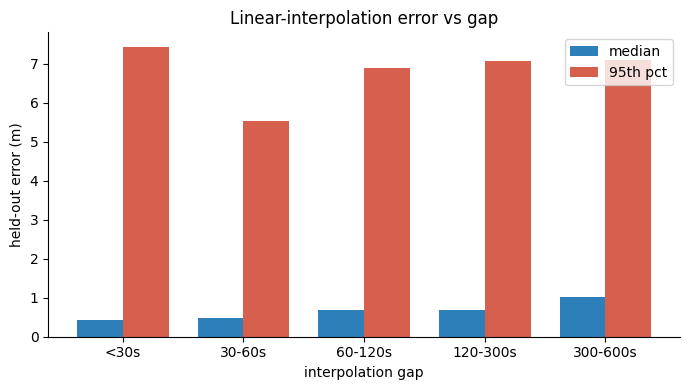

In [2]:
def err_query(bucket_sql: str, tail_sql: str) -> str:
    """Held-out interpolation error, bucketed by `bucket_sql`.

    Built from a template rather than by string-replacing a finished query: the
    bucket CASE spans two lines, so a single-line .replace() silently missed it and
    left a bare `gap` with no GROUP BY.
    """
    return f"""
WITH pts AS (
  SELECT mmsi, event_time AS t, latitude AS lat, longitude AS lon
  FROM read_parquet('{RAW_GLOB}')
  WHERE mobile_type='Class A' AND latitude BETWEEN {LATMIN} AND {LATMAX}
    AND longitude BETWEEN {LONMIN} AND {LONMAX}
  QUALIFY row_number() OVER (PARTITION BY mmsi, event_time ORDER BY t)=1),
w AS (SELECT mmsi,t,lat,lon,
        lag(t) OVER q tp, lag(lat) OVER q latp, lag(lon) OVER q lonp,
        lead(t) OVER q tn, lead(lat) OVER q latn, lead(lon) OVER q lonn
      FROM pts WINDOW q AS (PARTITION BY mmsi ORDER BY t)),
tri AS (SELECT *, epoch(t)-epoch(tp) g1, epoch(tn)-epoch(t) g2, epoch(tn)-epoch(tp) gap FROM w
        WHERE tp IS NOT NULL AND tn IS NOT NULL),
interp AS (
  SELECT gap, lat, lon,
    latp+(epoch(t)-epoch(tp))/(epoch(tn)-epoch(tp))*(latn-latp) lat_i,
    lonp+(epoch(t)-epoch(tp))/(epoch(tn)-epoch(tp))*(lonn-lonp) lon_i,
    -- implied speed of the bracketing leg (m/s); drop teleports (>100 kn ~ 51 m/s)
    sqrt(power((lonn-lonp)*111320*cos(radians(lat)),2)+power((latn-latp)*110540,2))/nullif(gap,0) v
  FROM tri WHERE gap BETWEEN 2 AND 600 AND g1>0 AND g2>0),
err AS (SELECT gap, sqrt(power((lon-lon_i)*111320*cos(radians(lat)),2)
                       + power((lat-lat_i)*110540,2)) err_m
        FROM interp WHERE v < 51)
SELECT {bucket_sql} bucket,
       count(*) n, round(median(err_m),2) med_m,
       round(quantile_cont(err_m,0.90),2) p90_m, round(quantile_cont(err_m,0.95),2) p95_m
FROM err {tail_sql};"""


BUCKET = ("CASE WHEN gap<30 THEN '<30s' WHEN gap<60 THEN '30-60s' "
          "WHEN gap<120 THEN '60-120s' WHEN gap<300 THEN '120-300s' "
          "ELSE '300-600s' END")

by_gap = con.execute(err_query(BUCKET, "GROUP BY 1 ORDER BY min(gap)")).fetchdf()
print(by_gap.to_string(index=False))
overall = con.execute(err_query("'all'", "")).fetchdf()
print("\nOVERALL:"); print(overall.to_string(index=False))

# persist for the thesis table/figure: per-bucket rows + an 'all' row, tagged with the source day
interp_out = pd.concat([by_gap, overall], ignore_index=True)
interp_out.insert(0, "source", RAW_GLOB)
interp_out.to_csv("results/l0_validation_interp.csv", index=False)
print("\nwrote results/l0_validation_interp.csv")

import numpy as np
x=np.arange(len(by_gap)); wd=0.38
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(x-wd/2,by_gap.med_m,wd,label="median",color="#2c7fb8")
ax.bar(x+wd/2,by_gap.p95_m,wd,label="95th pct",color="#d6604d")
ax.set_xticks(x); ax.set_xticklabels(by_gap.bucket); ax.set_ylabel("held-out error (m)")
ax.set_xlabel("interpolation gap"); ax.set_title("Linear-interpolation error vs gap")
ax.legend(); ax.spines[["top","right"]].set_visible(False); plt.tight_layout()
fig.savefig("figures/l0_interp_error.png", dpi=200, bbox_inches="tight")
plt.show()

**How to read it.** Median error at the metre level and the 95th percentile within a few metres, even
across multi-minute gaps, means L0's interpolated path is very close to the observed positions. So the
Chapter-5 linear-interpolation assumption introduces only a few metres of positional uncertainty, and
"recall against L0" is a sound reference rather than an arbitrary one. (Reference result on 2026-01-15:
median ~0.5 m, p95 ~7 m.)

## 3. Cleaning / population audit: how far L0's population is from the raw feed

In [4]:
audit=con.execute(f"""
  WITH raw AS (SELECT * FROM read_parquet('{RAW_GLOB}')),
  classA AS (SELECT * FROM raw WHERE mobile_type='Class A'
             AND latitude BETWEEN {LATMIN} AND {LATMAX} AND longitude BETWEEN {LONMIN} AND {LONMAX})
  SELECT
    (SELECT count(*) FROM raw)                        AS raw_messages,
    (SELECT count(DISTINCT mmsi) FROM raw)            AS raw_vessels,
    (SELECT count(*) FROM classA)                     AS classA_messages,
    (SELECT count(DISTINCT mmsi) FROM classA)         AS classA_vessels,
    (SELECT count(*) FROM (SELECT DISTINCT mmsi,event_time FROM classA)) AS classA_dedup_messages
""").fetchdf()
print(audit.T.to_string(header=False))

audit_out = audit.copy()
audit_out.insert(0, "source", RAW_GLOB)
# derived reduction ratios, so the table can be quoted directly
audit_out["classA_msg_pct_of_raw"]   = (100*audit.classA_messages/audit.raw_messages).round(2)
audit_out["classA_vessel_pct_of_raw"]= (100*audit.classA_vessels/audit.raw_vessels).round(2)
audit_out["dedup_pct_of_classA"]     = (100*audit.classA_dedup_messages/audit.classA_messages).round(2)
audit_out.to_csv("results/l0_validation_audit.csv", index=False)
print("\nwrote results/l0_validation_audit.csv")
print("\nThese bound the raw->L0 reduction (Class-A only, dedup, in-bbox). Cross-check against Table 6.x /"
      " ds-quality; the gap to L0 vessel count is what cleaning + segmentation remove.")

raw_messages           16773395
raw_vessels                3258
classA_messages        14970090
classA_vessels             2314
classA_dedup_messages   8895694

wrote results/l0_validation_audit.csv

These bound the raw->L0 reduction (Class-A only, dedup, in-bbox). Cross-check against Table 6.x / ds-quality; the gap to L0 vessel count is what cleaning + segmentation remove.
